In [ ]:
from typing import ClassVar

import diffrax as dfx
import equinox as eqx
import grain
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from deep_isochron.misc import cartesian_to_polar
from deep_isochron.model.fourier import TruncatedFourier
from deep_isochron.model.invertible import (
    AbstractBijection,
    AffineCoupling,
    BiLipschitzLinear,
    CouplingFlow,
    CubicConjugation,
    InvertibleLinear,
    MonotonicRQCoupling,
    OffsetedBijection,
    SequentialINN,
    SinhConjugation,
)
from deep_isochron.model.latent_dynamics import (
    AbstractLatentDynamics,
)
from deep_isochron.systems.base import AbstractODE
from deep_isochron.systems.fitzhugh_nagumo import FitzhughNagumo
from deep_isochron.systems.normal_forms import BautinNormalForm, HopfNormalForm
from deep_isochron.training import TimeSeriesDataSource, Trainer
from jaxtyping import Array, Float, PRNGKeyArray


jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_device", jax.devices("gpu")[3])


In [2]:
normal_form = HopfNormalForm(a=1.0, w=10.0, w0=0.1)

normal_form2 = BautinNormalForm(a=1.0, b=0.5, w=10.0, w0=0.1)

In [3]:
normal_form.w0

Array(0.1, dtype=float64, weak_type=True)

In [4]:
ts = jnp.arange(0, 20.0, 0.01)
y0 = jax.random.uniform(jax.random.key(0), shape=(normal_form.dim,))

In [5]:
def polar_to_cartesian(rtheta):
    r, theta = rtheta
    return jnp.stack((r * jnp.cos(theta), r * jnp.sin(theta)))

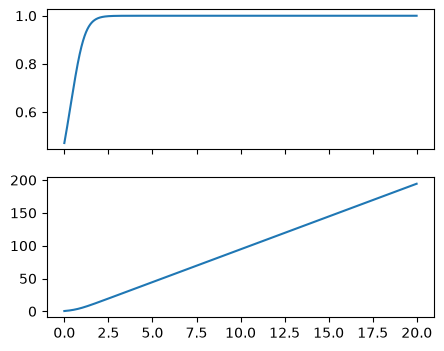

In [6]:
traj = normal_form2.solve(ts, cartesian_to_polar(y0))
fig, axes = plt.subplots(2, 1, figsize=(5, 4), sharex=True)
axes[0].plot(ts, traj[:, 0])
axes[1].plot(ts, traj[:, 1])

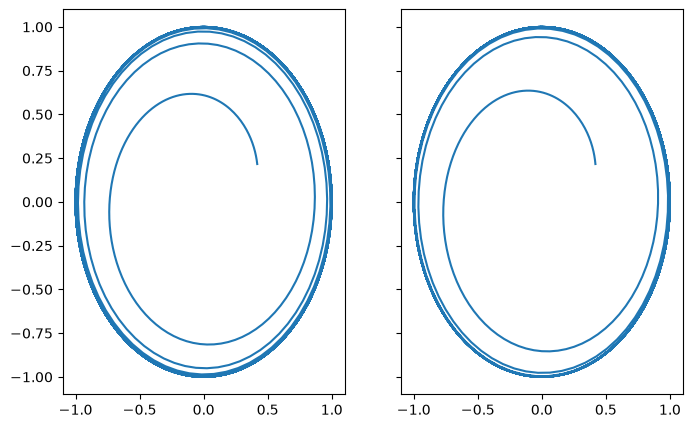

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharex=True, sharey=True)
for ax, nf in zip(axes, (normal_form, normal_form2)):
    traj = nf.solve(ts, cartesian_to_polar(y0))
    ax.plot(*polar_to_cartesian(traj.T))

In [8]:
class LatentDynamicsConverter(eqx.Module):
    latent_dynamics: AbstractLatentDynamics | AbstractODE
    bijection: AbstractBijection

    def __init__(
        self,
        latent_dynamics: AbstractLatentDynamics | AbstractODE,
        bijection: AbstractBijection,
    ):
        self.latent_dynamics = latent_dynamics
        self.bijection = bijection

    @property
    def dim(self) -> int:
        return self.latent_dynamics.dim

    def __call__(
        self,
        ts: Float[Array, " time"],
        x0: Float[Array, " obs_dim"],
        return_latent_trajectory: bool = True,
    ) -> tuple[Float[Array, "time obs_dim"], Float[Array, "time latent_dim"] | None]:
        y0: Float[Array, " latent_dim"] = self.bijection(x0)
        y0_polar = cartesian_to_polar(y0)
        yt_polar: Float[Array, "time latent_dim"] = self.latent_dynamics.solve(
            ts, y0_polar, max_steps=8192, atol=1e-6, rtol=1e-4, solver=dfx.Kvaerno5()
        )
        yt = jax.vmap(polar_to_cartesian)(yt_polar)
        xt: Float[Array, "time obs_dim"] = eqx.filter_vmap(self.bijection.inverse)(yt)

        if return_latent_trajectory:
            return xt, yt
        else:
            return xt, None


In [9]:
from deep_isochron.model.invertible import MonotonicRationalQuadraticSpline


class CircularMonotonicRQCoupling(AbstractBijection):
    """Circular variant of monotonic rational quadratic spline coupling transform, as
    introduced in [1, 2].

    [1] C. Durkan et al. Neural Spline Flows. NeurIPS (2019).
    [2] https://github.com/bayesiains/nflows/blob/master/nflows/transforms/splines/rational_quadratic.py
    """

    theta_offset: Float[Array, ""]
    _dxs: Float[Array, " knots-1"]
    _dys: Float[Array, " knots-1"]
    _derivs: Float[Array, " knots-1"]

    dim: ClassVar[int] = 2  # ty: ignore
    num_knots: int = eqx.field(static=True)
    min_derivative: float = eqx.field(static=True)
    min_rel_x_bin_width: float = eqx.field(static=True)
    min_rel_y_bin_width: float = eqx.field(static=True)

    def __init__(
        self,
        num_knots: int = 10,
        min_rel_x_bin_width: float = 1e-3,
        min_rel_y_bin_width: float = 1e-3,
        min_derivative: float = 1e-3,
        dtype=None,
        *,
        key: PRNGKeyArray,
    ):
        """**Arguments:**

        - `dim`: Dimension of the inputs/outputs of the coupling transform.
        - `min_derivative`: Minimum value of the derivative at the knot points.


        """
        key_x, key_y, key_d = jax.random.split(key, 3)
        self._dxs = jnp.ones(
            (num_knots - 1,)
        )  # jax.random.normal(key_x, (num_knots-1,))
        self._dys = jnp.ones(
            (num_knots - 1,)
        )  # jax.random.normal(key_y, (num_knots-1,))
        self._derivs = jnp.ones(
            (num_knots - 1,)
        )  # jax.random.normal(key_d, (num_knots-1,))
        self.theta_offset = jnp.zeros(())
        self.num_knots = num_knots
        self.min_rel_x_bin_width = min_rel_x_bin_width
        self.min_rel_y_bin_width = min_rel_y_bin_width
        self.min_derivative = min_derivative

    def _make_knots(
        self,
        unnormalized_bin_widths: Float[Array, " {self.num_knots}-1"],
        min_bin_width: float,
    ) -> Float[Array, " {self.num_knots}"]:
        bin_widths = (
            jax.nn.softmax(unnormalized_bin_widths)
            * (1 - self.num_knots * min_bin_width)
            + min_bin_width
        )
        knots = jnp.pad(jnp.cumsum(bin_widths), pad_width=(1, 0))
        return -jnp.pi + 2 * jnp.pi * knots

    def make_spline(self) -> MonotonicRationalQuadraticSpline:
        xs = self._make_knots(self._dxs, self.min_rel_x_bin_width)
        ys = self._make_knots(self._dys, self.min_rel_y_bin_width)
        ds = jnp.pad(
            jax.nn.softplus(self._derivs) + self.min_derivative,
            pad_width=(1, 0),
            mode="wrap",
        )
        return MonotonicRationalQuadraticSpline(xs, ys, ds)

    def __call__(self, x: Float[Array, " 2"]) -> Float[Array, " 2"]:
        r, theta = cartesian_to_polar(x)
        # theta = jnp.mod(theta-self.theta_offset, 2*jnp.pi)-jnp.pi
        spl = self.make_spline()
        theta_out = jnp.piecewise(
            theta,
            [theta < -jnp.pi, theta > jnp.pi],
            [lambda x: x, lambda x: x, lambda x: spl(x)],
        )
        return jnp.stack([r * jnp.cos(theta_out), r * jnp.sin(theta_out)])

    def inverse(self, y: Float[Array, " dim"]) -> Float[Array, " dim"]:
        r, theta = cartesian_to_polar(y)
        # theta = jnp.mod(theta, 2*jnp.pi)-jnp.pi
        spl = self.make_spline()
        theta_in = jnp.piecewise(
            theta,
            [theta < -jnp.pi, theta > jnp.pi],
            [lambda x: x, lambda x: x, lambda x: spl.inverse(x)],
        )
        # theta_in = theta_in+self.theta_offset
        return jnp.stack([r * jnp.cos(theta_in), r * jnp.sin(theta_in)])


class PolarConditionalBijection(AbstractBijection):
    dim: ClassVar[int] = 2

    center: Float[Array, " dim"]
    log_scale: Float[Array, " dim"]

    fourier: TruncatedFourier

    eps_r: float = eqx.field(static=True)

    def __init__(
        self,
        n_radial_blocks: int,
        fourier_order: int = 3,
        init_scale: float = 0.01,
        eps_r: float = 1e-7,
        *,
        key: PRNGKeyArray,
    ):
        key_c, key_s, key_f = jax.random.split(key, 3)
        self.center = jax.random.normal(key_c, (2,)) * init_scale
        self.log_scale = jax.random.normal(key_s, (2,)) * init_scale
        self.fourier = TruncatedFourier(
            dim=n_radial_blocks * 5,
            order=fourier_order,
            init_scale=init_scale,
            key=key_f,
        )
        self.eps_r = eps_r

    @property
    def scale(self) -> Float[Array, " dim"]:
        return jnp.exp(self.log_scale)

    def __call__(self, x: Float[Array, " 2"]) -> Float[Array, " 2"]:
        x_scaled = (x - self.center) * self.scale
        r_in = jnp.sqrt(jnp.sum(x_scaled**2) + self.eps_r**2)

        theta = jnp.arctan2(x_scaled[1], x_scaled[0])
        params = jnp.reshape(self.fourier(theta), (-1, 5))
        radial_bijection = OffsetedBijection(
            SequentialINN(
                [SinhConjugation.from_unnormalized_params(*p) for p in params]
            )
        )

        r_out = radial_bijection(r_in)

        y_scaled = (r_out / r_in) * x_scaled
        return (y_scaled / self.scale) + self.center

    def inverse(self, y: Float[Array, " 2"]) -> Float[Array, " 2"]:
        y_scaled = (y - self.center) * self.scale
        r_out = jnp.sqrt(jnp.sum(y_scaled**2) + self.eps_r**2)

        theta = jnp.arctan2(y_scaled[1], y_scaled[0])
        params = jnp.reshape(self.fourier(theta), (-1, 5))
        radial_bijection = OffsetedBijection(
            SequentialINN(
                [SinhConjugation.from_unnormalized_params(*p) for p in params]
            )
        )

        r_in = radial_bijection.inverse(r_out)

        x_scaled = (r_in / r_out) * y_scaled
        return (x_scaled / self.scale) + self.center

In [ ]:
from collections.abc import Callable

import equinox as eqx
import jax
from jaxtyping import Array, Float, PRNGKeyArray


class ResNet(eqx.Module):
    """Residual neural network."""

    layers: tuple[eqx.nn.Conv, ...]

    in_size: int = eqx.field(static=True)
    out_size: int = eqx.field(static=True)
    activation: Callable[[Array], Array] = eqx.field(static=True)
    final_activation: Callable[[Array], Array] = eqx.field(static=True)

    def __init__(
        self,
        in_size: int,
        out_size: int,
        width_size: int,
        depth: int,
        activation: Callable = jax.nn.gelu,
        final_activation: Callable = lambda x: x,
        dtype=None,
        *,
        key: PRNGKeyArray,
    ):
        keys = jax.random.split(key, depth + 1)

        layers = []
        if depth == 0:
            layers.append(
                eqx.nn.Linear(in_features=in_size, out_features=out_size, key=keys[0])
            )
        else:
            layers.append(
                eqx.nn.Linear(in_features=in_size, out_features=width_size, key=keys[0])
            )
            layers.extend(
                eqx.nn.Linear(
                    in_features=width_size, out_features=width_size, key=keys[i]
                )
                for i in range(1, depth)
            )
            layers.append(
                eqx.nn.Linear(in_features=in_size, out_features=out_size, key=keys[-1])
            )
        self.layers = tuple(layers)

        self.in_size = in_size
        self.out_size = out_size
        self.activation = activation
        self.final_activation = final_activation

    def __call__(
        self,
        x: Float[Array, " in_size"],
        *,
        key: PRNGKeyArray | None = None,
    ) -> Float[Array, " out_size"]:
        del key
        for layer in self.layers[:-1]:
            x = x + self.activation(layer(x))
        return x + self.final_activation(self.layers[-1](x))


In [10]:
def make_invertible_block(key: PRNGKeyArray):
    key_l, key_c = jax.random.split(key)
    linear = InvertibleLinear(dim=2, key=key_l)
    # linear = BiLipschitzLinear(dim=2, max_lipschitz=2.0, key=key_l)
    coupling = MonotonicRQCoupling(
        dim=2,
        width_hidden=32,
        num_knots=10,
        xy_range=(-4, 4),
        key=key_c,
    )
    return (linear, coupling)


num_blocks = 8
autoencoder = LatentDynamicsConverter(
    latent_dynamics=BautinNormalForm(
        a=1.0, b=0.5, w=-2 * jnp.pi / 10.0, w0=2 * jnp.pi / 10.0
    ),
    bijection=SequentialINN(
        sum(
            (make_invertible_block(jax.random.key(k)) for k in range(num_blocks)),
            start=(),
        )
        # + (CircularMonotonicRQCoupling(num_knots=10, key=jax.random.key(10)),)
    ),
)

In [9]:
def make_invertible_block(key: PRNGKeyArray, flip: bool):
    key_l, key_c = jax.random.split(key)
    linear = InvertibleLinear(dim=2, key=key_l)
    # linear = BiLipschitzLinear(dim=2, max_lipschitz=2.0, key=key_l)
    bijection = SequentialINN(
        [
            CubicConjugation(*jax.random.normal(k, (4,)))
            for k in jax.random.split(jax.random.key(0), 3)
        ]
    )
    coupling = CouplingFlow(
        dim=2,
        bijection=bijection,
        mlp_width=128,
        flip=flip,
        key=key_c,
    )
    return (linear, coupling)


num_blocks = 8
autoencoder = LatentDynamicsConverter(
    latent_dynamics=BautinNormalForm(
        a=1.0, b=0.5, w=-2 * jnp.pi / 10.0, w0=2 * jnp.pi / 10.0
    ),
    bijection=SequentialINN(
        sum(
            (
                make_invertible_block(jax.random.key(k), flip=(k % 2 == 0))
                for k in range(num_blocks)
            ),
            start=(),
        )
    ),
)

In [ ]:
def make_invertible_block(key: PRNGKeyArray):
    key_l, key_c = jax.random.split(key)
    # linear = InvertibleLinear(dim=2, key=key_l)
    linear = BiLipschitzLinear(dim=2, max_lipschitz=2.0, key=key_l)
    coupling = AffineCoupling(
        dim=2,
        width_hidden=32,
        affine_clamping=3.0,
        key=key_c,
    )
    return (linear, coupling)


num_blocks = 7
autoencoder = LatentDynamicsConverter(
    latent_dynamics=BautinNormalForm(
        a=1.0, b=0.5, w=-2 * jnp.pi / 10.0, w0=2 * jnp.pi / 10.0
    ),
    bijection=SequentialINN(
        sum(
            (make_invertible_block(jax.random.key(k)) for k in range(num_blocks)),
            start=(),
        )
    ),
)

In [10]:
autoencoder = LatentDynamicsConverter(
    latent_dynamics=BautinNormalForm(
        a=1.0, b=0.5, w=-2 * jnp.pi / 10.0, w0=2 * jnp.pi / 10.0
    ),
    bijection=SequentialINN(
        [
            PolarConditionalBijection(n_radial_blocks=7, fourier_order=5, key=k)
            for k in jax.random.split(jax.random.key(10), 5)
        ]
    ),
)

NameError: name 'PolarConditionalBijection' is not defined

## Generate data for Fitahugh-Nagumo

In [10]:
ode = FitzhughNagumo()

u0 = jnp.asarray([1.0, 0.0])
t = jnp.linspace(0, 100, 1000)
sol = dfx.diffeqsolve(
    dfx.ODETerm(ode.rhs),
    dfx.Tsit5(),
    t[0],
    t[-1],
    None,
    u0,
    stepsize_controller=dfx.PIDController(rtol=1e-6, atol=1e-6),
    saveat=dfx.SaveAt(ts=t),
)

In [11]:
n_trajs = 1000
t_end = 20
t = jnp.arange(0, t_end + 0.01, 0.01)


def solve_single(
    ode,
    ts: Float[Array, " time"],
    u0: Float[Array, " dim"],
    rtol: float = 1e-8,
    atol: float = 1e-10,
    solver: dfx.AbstractSolver = dfx.Tsit5(),
):
    sol: dfx.Solution = dfx.diffeqsolve(
        dfx.ODETerm(ode.rhs),
        solver,
        ts[0],
        ts[-1],
        None,
        u0,
        stepsize_controller=dfx.PIDController(rtol=rtol, atol=atol),
        saveat=dfx.SaveAt(ts=t),
    )
    return sol.ys


u0_train = jax.random.uniform(
    jax.random.key(0), (n_trajs, ode.dim), minval=-3, maxval=3
)
u_train = eqx.filter_vmap(solve_single, in_axes=(None, None, 0))(ode, t, u0_train)
print(u_train.shape)

(1000, 2002, 2)


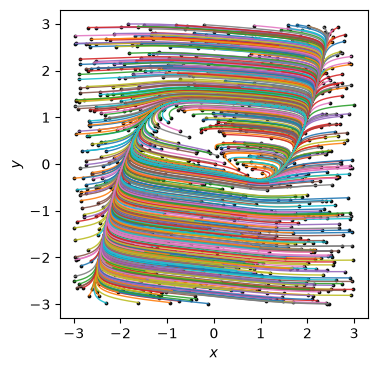

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
for i in range(0, len(u_train)):
    ax.plot(*u_train[i].T, alpha=0.9, linewidth=1.0)
ax.scatter(*u_train[:, 0].T, s=3, color="black", alpha=0.9)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_aspect("equal")

In [13]:
source = TimeSeriesDataSource(ts=t, ys=u_train, window_size=100)
s1, s2 = source.split(100)
ds1 = grain.MapDataset.source(s1).seed(0).shuffle().repeat()
ds2 = grain.MapDataset.source(s2).seed(1).shuffle().repeat()

In [14]:
ds_combine = grain.MapDataset.mix([ds1, ds2], weights=(1, 1))

In [15]:
batch1 = next(iter(ds1.batch(batch_size=2048, drop_remainder=True)))
batch2 = next(iter(ds2.batch(batch_size=2048, drop_remainder=True)))

In [16]:
batch_combine = next(iter(ds_combine.batch(batch_size=2048, drop_remainder=True)))

In [17]:
batch1

(array([[0.  , 0.01, 0.02, ..., 0.97, 0.98, 0.99],
        [0.  , 0.01, 0.02, ..., 0.97, 0.98, 0.99],
        [0.  , 0.01, 0.02, ..., 0.97, 0.98, 0.99],
        ...,
        [0.  , 0.01, 0.02, ..., 0.97, 0.98, 0.99],
        [0.  , 0.01, 0.02, ..., 0.97, 0.98, 0.99],
        [0.  , 0.01, 0.02, ..., 0.97, 0.98, 0.99]], shape=(2048, 100)),
 array([[[-1.89667226, -0.86259759],
         [-1.92203943, -0.85161346],
         [-1.94512063, -0.84057798],
         ...,
         [-1.90387625,  0.10923073],
         [-1.90070399,  0.11760258],
         [-1.89752979,  0.12594157]],
 
        [[-2.62993995,  2.66888142],
         [-2.4724993 ,  2.67258956],
         [-2.33744134,  2.67580282],
         ...,
         [ 2.29411182,  2.0872262 ],
         [ 2.29273724,  2.07636329],
         [ 2.291222  ,  2.06553414]],
 
        [[-0.3053676 ,  1.19015705],
         [-0.29033253,  1.19030936],
         [-0.27487483,  1.19041052],
         ...,
         [ 1.91291752,  0.81899392],
         [ 1.9127870

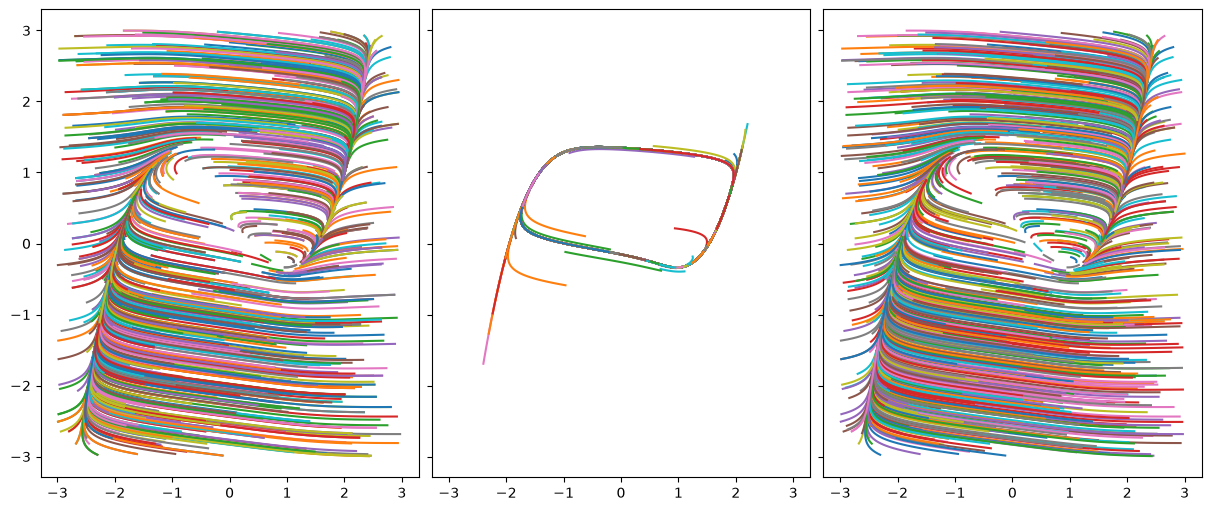

In [18]:
fig, axes = plt.subplots(
    1, 3, figsize=(12, 5), constrained_layout=True, sharex=True, sharey=True
)
for i in range(0, len(batch1[1]), 2):
    axes[0].plot(*batch1[1][i].T)
    axes[1].plot(*batch2[1][i].T)
    axes[2].plot(*batch_combine[1][i].T)

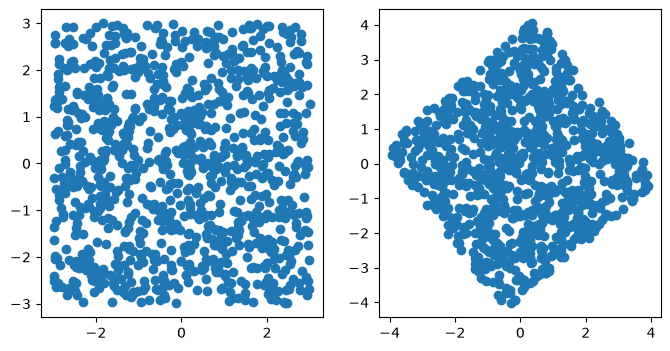

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].scatter(*u_train[:, 0].T)
axes[1].scatter(*eqx.filter_vmap(autoencoder.bijection)(u_train[:, 0]).T)

In [20]:
u_train.shape

(1000, 2002, 2)

In [21]:
u_pred, y_pred = eqx.filter_vmap(autoencoder, in_axes=(None, 0))(t, u_train[:, 0])
u_pred.shape

(1000, 2002, 2)

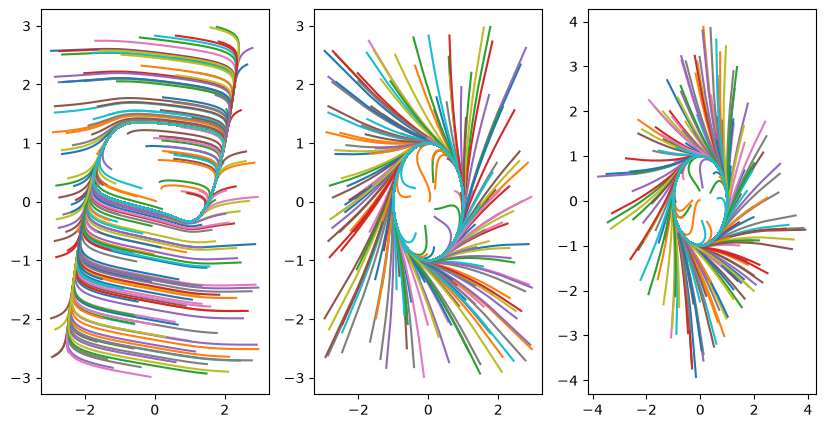

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
for i in range(0, len(u_pred), 5):
    axes[0].plot(*u_train[i].T)
    axes[1].plot(*u_pred[i].T)
    axes[2].plot(*y_pred[i].T)

In [23]:
u_train_ae = eqx.filter_vmap(
    lambda x: autoencoder.bijection.inverse(autoencoder.bijection(x))
)(u_train[:, 0])
jnp.max(jnp.abs(u_train[:, 0] - u_train_ae))

Array(3.55271368e-15, dtype=float64)

In [24]:
def loss_inn(model: LatentDynamicsConverter, batch, args=None):
    t_batch: Float[Array, "batch time"]
    x_batch: Float[Array, "batch time dim"]
    t_batch, x_batch = batch
    x_pred, y_pred = eqx.filter_vmap(model)(t_batch, x_batch[:, 0])
    # y_pred: Float[Array, "batch time latent_dim"] = eqx.filter_vmap(
    #     lambda t, x0: model.latent_dynamics(t, model.encoder(x0))
    # )(t_batch, x_batch[:, 0])
    # # x_pred: Float[Array, "batch time dim"] = eqx.filter_vmap(model)(
    # #     t_batch, x_batch[:, 0]
    # # )
    # x_pred = jax.vmap(jax.vmap(model.decoder))(y_pred)
    mse = jnp.mean((x_batch - x_pred) ** 2)

    y_batch = jax.vmap(jax.vmap(model.bijection))(x_batch)
    mse_latent = jnp.mean((y_batch - y_pred) ** 2)

    # x_ae = jax.vmap(jax.vmap(model.decoder))(y_batch)
    # y_ae = jax.vmap(jax.vmap(model.encoder))(x_ae)
    # loss_identity = jnp.mean((x_batch - x_ae) ** 2)
    # loss_identity_latent = jnp.mean((y_batch - y_ae) ** 2)

    # Weighting the latent space mse by 0
    return mse + 0 * mse_latent, {
        "mse": mse,
        # "identity_loss": loss_identity,
        # "identity_latent_loss": loss_identity_latent,
        "mse_latent": mse_latent,
    }

In [25]:
batch_pred = eqx.filter_vmap(autoencoder)(batch_combine[0], batch_combine[1][:, 0])[0]

In [26]:
batch_pred.shape

(2048, 100, 2)

In [27]:
batch_pred[i].shape

(100, 2)

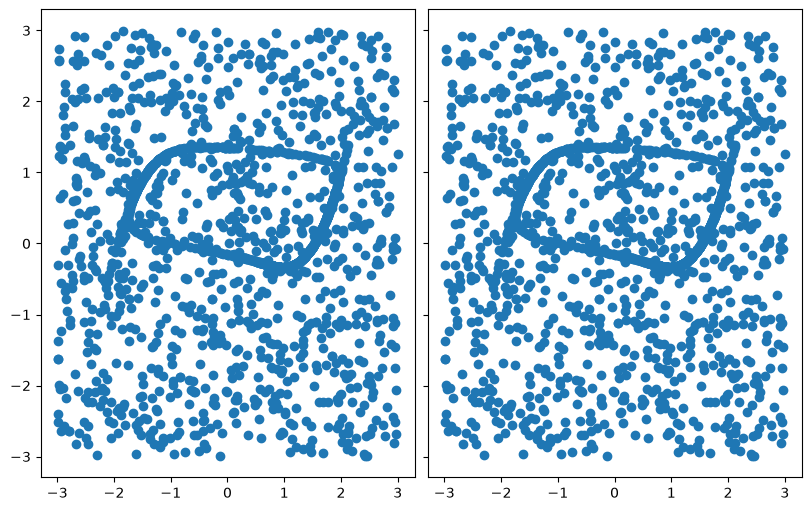

In [28]:
fig, axes = plt.subplots(
    1, 2, figsize=(8, 5), constrained_layout=True, sharex=True, sharey=True
)

axes[0].scatter(*batch_combine[1][:, 0].T)
axes[1].scatter(*batch_pred[:, 0].T)

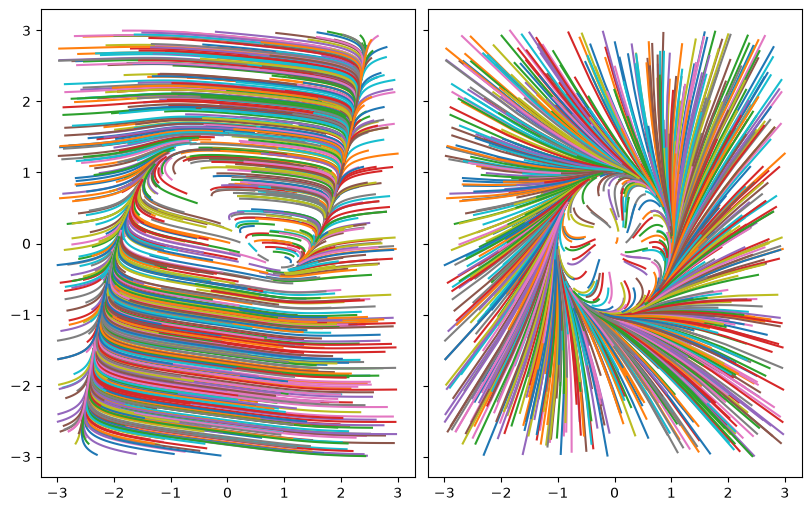

In [29]:
fig, axes = plt.subplots(
    1, 2, figsize=(8, 5), constrained_layout=True, sharex=True, sharey=True
)
for i in range(0, len(batch_combine[1]), 2):
    axes[0].plot(*batch_combine[1][i].T)
    axes[1].plot(*batch_pred[i].T)
# axes[0].set_xlim((-3.5, 3.5))
# axes[0].set_ylim((-3.5, 3.5))

In [30]:
loader_train = (
    ds_combine.batch(batch_size=2048, drop_remainder=True)
    .to_iter_dataset(read_options=grain.ReadOptions(prefetch_buffer_size=100))
    .map(  # batches buffered on host
        lambda x: jax.device_put(x, jax.extend.backend.get_default_device())
    )
)
loader_train = grain.experimental.ThreadPrefetchIterDataset(
    loader_train,
    prefetch_buffer_size=100,  # batches buffered on device
)

In [31]:
trainer = Trainer(
    optax.adamw(learning_rate=5e-4),
    loss_inn,
    "./",
    None,
    {"entity": "jhko725", "project": "isochron"},
    config_dict={"model": ""},
)

In [32]:
model = trainer.train(
    autoencoder,
    loader_train,
    None,
    num_steps=5000,
    seed=0,
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/jhko725/.netrc.
wandb: Currently logged in as: jhko725 (jhelab) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step: 0 | Train loss: 0.6700864363117222
Step: 1 | Train loss: 0.6340710002547975
Step: 2 | Train loss: 0.6150048026608115
Step: 3 | Train loss: 0.5835973401915852
Step: 4 | Train loss: 0.5801820051530061
Step: 5 | Train loss: 0.544052932023282
Step: 6 | Train loss: 0.5263727873430949
Step: 7 | Train loss: 0.5050964205700119
Step: 8 | Train loss: 0.49446606496454776
Step: 9 | Train loss: 0.47645978345213325
Step: 10 | Train loss: 0.4604476248420316
Step: 11 | Train loss: 0.44942740829731165
Step: 12 | Train loss: 0.4297373247768602
Step: 13 | Train loss: 0.4382403999856993
Step: 14 | Train loss: 0.41102425906997925
Step: 15 | Train loss: 0.4015202790309739
Step: 16 | Train loss: 0.39118105075186044
Step: 17 | Train loss: 0.38139538009634094
Step: 18 | Train loss: 0.36093652610739396
Step: 19 | Train loss: 0.3568801853520134
Step: 20 | Train loss: 0.34897372815710653
Step: 21 | Train loss: 0.3445789412266767
Step: 22 | Train loss: 0.3260014252078027
Step: 23 | Train loss: 0.312724284468

Step: 227 | Train loss: 0.06700076222426116
Step: 228 | Train loss: 0.06882034849664785
Step: 229 | Train loss: 0.06864167559687169
Step: 230 | Train loss: 0.06669403761185815
Step: 231 | Train loss: 0.06585287122477562
Step: 232 | Train loss: 0.06759489931627778
Step: 233 | Train loss: 0.06774834834303668
Step: 234 | Train loss: 0.0681933836653664
Step: 235 | Train loss: 0.06792377524929265
Step: 236 | Train loss: 0.06403872469328097
Step: 237 | Train loss: 0.06747515358602321
Step: 238 | Train loss: 0.06772321472561077
Step: 239 | Train loss: 0.06455448227211943
Step: 240 | Train loss: 0.06749724429790281
Step: 241 | Train loss: 0.06425627550475575
Step: 242 | Train loss: 0.06494798017107016
Step: 243 | Train loss: 0.06299779086131842
Step: 244 | Train loss: 0.0667441868425104
Step: 245 | Train loss: 0.06492551575610618
Step: 246 | Train loss: 0.06491479206887706
Step: 247 | Train loss: 0.06346564774062846
Step: 248 | Train loss: 0.06338127124164909
Step: 249 | Train loss: 0.06326154

Step: 542 | Train loss: 0.01850548000741543
Step: 543 | Train loss: 0.018375972774633178
Step: 544 | Train loss: 0.018383083308302767
Step: 545 | Train loss: 0.017616147501165264
Step: 546 | Train loss: 0.01861684041172841
Step: 547 | Train loss: 0.01739261847265608
Step: 548 | Train loss: 0.01832591431043719
Step: 549 | Train loss: 0.017437639132708006
Step: 550 | Train loss: 0.018237205902758614
Step: 551 | Train loss: 0.018306308952287513
Step: 552 | Train loss: 0.017980131519080178
Step: 553 | Train loss: 0.017375053323708128
Step: 554 | Train loss: 0.018176894836989543
Step: 555 | Train loss: 0.017223544754981456
Step: 556 | Train loss: 0.017967829609058704
Step: 557 | Train loss: 0.017568830499030737
Step: 558 | Train loss: 0.01747142489708093
Step: 559 | Train loss: 0.016887194655630298
Step: 560 | Train loss: 0.01726663582866132
Step: 561 | Train loss: 0.016775317100503628
Step: 562 | Train loss: 0.017018474512144
Step: 563 | Train loss: 0.016383566076841046
Step: 564 | Train l

Step: 860 | Train loss: 0.010482964317438814
Step: 861 | Train loss: 0.009811714035149246
Step: 862 | Train loss: 0.010402145462060032
Step: 863 | Train loss: 0.009997262452261232
Step: 864 | Train loss: 0.010405582981923064
Step: 865 | Train loss: 0.0102824174557253
Step: 866 | Train loss: 0.01098526967710865
Step: 867 | Train loss: 0.011202942386895284
Step: 868 | Train loss: 0.011983390794429716
Step: 869 | Train loss: 0.01171379655921625
Step: 870 | Train loss: 0.01138098071047731
Step: 871 | Train loss: 0.010537729217767487
Step: 872 | Train loss: 0.010069877490402827
Step: 873 | Train loss: 0.010008434097830327
Step: 874 | Train loss: 0.010537544872620451
Step: 875 | Train loss: 0.010663047159869286
Step: 876 | Train loss: 0.010340152751593697
Step: 877 | Train loss: 0.009866688183917836
Step: 878 | Train loss: 0.010045816696039954
Step: 879 | Train loss: 0.010371170824506835
Step: 880 | Train loss: 0.010683908017618095
Step: 881 | Train loss: 0.010660321038409953
Step: 882 | Tra

...

Step: 3860 | Train loss: 0.004197992147646544
Step: 3861 | Train loss: 0.003994152218085949
Step: 3862 | Train loss: 0.004023496992869338
Step: 3863 | Train loss: 0.003681543116804262
Step: 3864 | Train loss: 0.003955141233988177
Step: 3865 | Train loss: 0.004194938576536507
Step: 3866 | Train loss: 0.004065055737438129
Step: 3867 | Train loss: 0.0041322017879659315
Step: 3868 | Train loss: 0.0039378687038396755
Step: 3869 | Train loss: 0.003882455789082008
Step: 3870 | Train loss: 0.003920068652461999
Step: 3871 | Train loss: 0.003883669695429795
Step: 3872 | Train loss: 0.004013656075136604
Step: 3873 | Train loss: 0.0038803187860572855
Step: 3874 | Train loss: 0.003964416746718333
Step: 3875 | Train loss: 0.003910490490113016
Step: 3876 | Train loss: 0.0038726543931695756
Step: 3877 | Train loss: 0.0037756108758556146
Step: 3878 | Train loss: 0.003935358562004271
Step: 3879 | Train loss: 0.00385782301183808
Step: 3880 | Train loss: 0.003815624822559674
Step: 3881 | Train loss: 0.003

Step: 4211 | Train loss: 0.0037517520954663017
Step: 4212 | Train loss: 0.00360494444098523
Step: 4213 | Train loss: 0.00383908942555785
Step: 4214 | Train loss: 0.003779137036398751
Step: 4215 | Train loss: 0.0038650840846351886
Step: 4216 | Train loss: 0.003942480831948323
Step: 4217 | Train loss: 0.004010735196903466
Step: 4218 | Train loss: 0.0036710209792067926
Step: 4219 | Train loss: 0.003933492863574079
Step: 4220 | Train loss: 0.0037413045971291317
Step: 4221 | Train loss: 0.0038093412145872277
Step: 4222 | Train loss: 0.003623630321370721
Step: 4223 | Train loss: 0.0037122736522648605
Step: 4224 | Train loss: 0.0037265196716462657
Step: 4225 | Train loss: 0.004027564929163786
Step: 4226 | Train loss: 0.0039878232717424945
Step: 4227 | Train loss: 0.004009559624357969
Step: 4228 | Train loss: 0.003696602348268881
Step: 4229 | Train loss: 0.003827601642450369
Step: 4230 | Train loss: 0.00393536472420167
Step: 4231 | Train loss: 0.003962678873029308
Step: 4232 | Train loss: 0.00

Step: 4565 | Train loss: 0.003548340888555503
Step: 4566 | Train loss: 0.0037487970418600813
Step: 4567 | Train loss: 0.0041157295428866595
Step: 4568 | Train loss: 0.004211825601511583
Step: 4569 | Train loss: 0.004603253983357983
Step: 4570 | Train loss: 0.0047707287870973804
Step: 4571 | Train loss: 0.00502932138607075
Step: 4572 | Train loss: 0.004559247780104432
Step: 4573 | Train loss: 0.004355401485816464
Step: 4574 | Train loss: 0.0036930352889555495
Step: 4575 | Train loss: 0.003808656924219792
Step: 4576 | Train loss: 0.004021664205934262
Step: 4577 | Train loss: 0.004090040082637117
Step: 4578 | Train loss: 0.003831024464205549
Step: 4579 | Train loss: 0.0036219412866303315
Step: 4580 | Train loss: 0.003806707608797746
Step: 4581 | Train loss: 0.003972489082764798
Step: 4582 | Train loss: 0.004036978818191437
Step: 4583 | Train loss: 0.0037915857386956998
Step: 4584 | Train loss: 0.00363333525897474
Step: 4585 | Train loss: 0.003630096487320367
Step: 4586 | Train loss: 0.003

Step: 4922 | Train loss: 0.003485803631616763
Step: 4923 | Train loss: 0.0034310367261024865
Step: 4924 | Train loss: 0.0034149775101413016
Step: 4925 | Train loss: 0.0033662733988050974
Step: 4926 | Train loss: 0.003572675647047112
Step: 4927 | Train loss: 0.0033883484487527774
Step: 4928 | Train loss: 0.003344762191860572
Step: 4929 | Train loss: 0.0033506702841199798
Step: 4930 | Train loss: 0.003530250675470556
Step: 4931 | Train loss: 0.0035043538983188854
Step: 4932 | Train loss: 0.00363462297261144
Step: 4933 | Train loss: 0.0034382655043427852
Step: 4934 | Train loss: 0.0036200511894267443
Step: 4935 | Train loss: 0.003231032949623541
Step: 4936 | Train loss: 0.003586093629633847
Step: 4937 | Train loss: 0.003554271047558748
Step: 4938 | Train loss: 0.0042575422138810964
Step: 4939 | Train loss: 0.004279607483798054
Step: 4940 | Train loss: 0.004297138349095107
Step: 4941 | Train loss: 0.004164104905932129
Step: 4942 | Train loss: 0.004258118993390285
Step: 4943 | Train loss: 0

mse,█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
mse_latent,█▃▃▃▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,██▆▅▄▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
mse,0.00464
mse_latent,0.01308
train_loss,0.00464


In [33]:
t_subset, u_train_subset = source.ts[::5], source.ys[::10, ::5]  # batch
u_pred_subset, w_pred_subset = eqx.filter_vmap(model, in_axes=(None, 0))(
    t_subset, u_train_subset[:, 0]
)

t_longer = jnp.arange(t_subset[0], 4 * t_subset[-1], t_subset[1] - t_subset[0])
u_longer = eqx.filter_vmap(model, in_axes=(None, 0))(t_longer, u_train_subset[:, 0])[0]

In [34]:
model.latent_dynamics.period()

Array(-11.79577219, dtype=float64)

In [35]:
model.latent_dynamics.eigenvalues_origin()

Array([0.76866259+0.46598471j, 0.76866259-0.46598471j], dtype=complex128)

In [36]:
model.latent_dynamics.a

Array(0.76866259, dtype=float64)

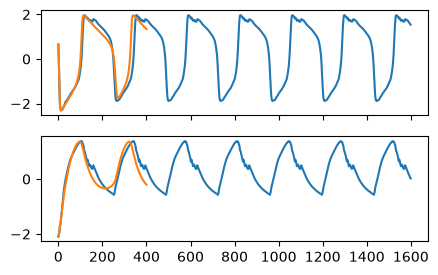

In [37]:
traj_idx = 50
fig, axes = plt.subplots(2, 1, figsize=(5, 3), sharex=True)
for i, ax in enumerate(axes):
    # ax.plot(u_pred_subset[traj_idx, :, i], "--")
    ax.plot(u_longer[traj_idx, :, i])
    ax.plot(u_train_subset[traj_idx, :, i])

# ax.set_xlim((1500,2000))

Text(0.5, 1.0, 'Model latent space')

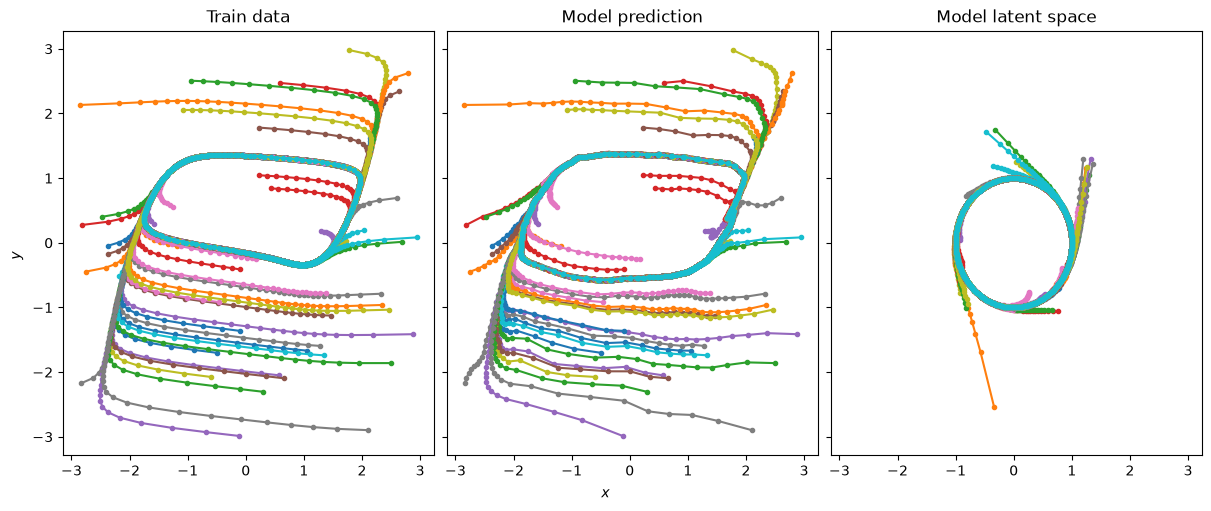

In [38]:
fig, axes = plt.subplots(
    1, 3, figsize=(12, 5), constrained_layout=True, sharex=True, sharey=True
)
for i in range(0, len(u_train_subset), 2):
    axes[0].plot(*u_train_subset[i].T, ".-")
    axes[1].plot(*u_pred_subset[i].T, ".-")
    axes[2].plot(*w_pred_subset[i].T, ".-")
# axes[0].set_xlim((-3.5, 3.5))
# axes[0].set_ylim((-3.5, 3.5))
fig.supxlabel("$x$", fontsize="medium")
fig.supylabel("$y$", fontsize="medium")
axes[0].set_title("Train data")
axes[1].set_title("Model prediction")
axes[2].set_title("Model latent space")

In [37]:
model_trained

LatentDynamicsConverter(
  latent_dynamics=BautinNormalForm(_a=f64[], _b=f64[], w=f64[], w0=f64[]),
  bijection=SequentialINN(
    transforms=(
      InvertibleLinear(weight=f64[2,2], bias=f64[2], dim=2),
      CouplingFlow(
        mlp=MLP(
          layers=(
            Linear(
              weight=f64[32,1],
              bias=f64[32],
              in_features=1,
              out_features=32,
              use_bias=True
            ),
            Linear(
              weight=f64[9,32],
              bias=f64[9],
              in_features=32,
              out_features=9,
              use_bias=True
            )
          ),
          activation=<PjitFunction of <function relu at 0x151615700c20>>,
          final_activation=<function <lambda>>,
          use_bias=True,
          use_final_bias=True,
          in_size=1,
          out_size=9,
          width_size=32,
          depth=1
        ),
        bijection_factory=BijectionFactory(
          _bijection_static=SequentialINN(


In [38]:
model_trained.bijection.transforms[-1]

CouplingFlow(
  mlp=MLP(
    layers=(
      Linear(
        weight=f64[32,1],
        bias=f64[32],
        in_features=1,
        out_features=32,
        use_bias=True
      ),
      Linear(
        weight=f64[9,32],
        bias=f64[9],
        in_features=32,
        out_features=9,
        use_bias=True
      )
    ),
    activation=<PjitFunction of <function relu at 0x151615700c20>>,
    final_activation=<function <lambda>>,
    use_bias=True,
    use_final_bias=True,
    in_size=1,
    out_size=9,
    width_size=32,
    depth=1
  ),
  bijection_factory=BijectionFactory(
    _bijection_static=SequentialINN(
      transforms=(
        CubicRational(
          _alpha=None, _beta=None, loc=None, eps_alpha=0.001, eps_beta=0.1
        ),
        CubicRational(
          _alpha=None, _beta=None, loc=None, eps_alpha=0.001, eps_beta=0.1
        ),
        CubicRational(
          _alpha=None, _beta=None, loc=None, eps_alpha=0.001, eps_beta=0.1
        )
      )
    ),
    unflatten_fn=<j

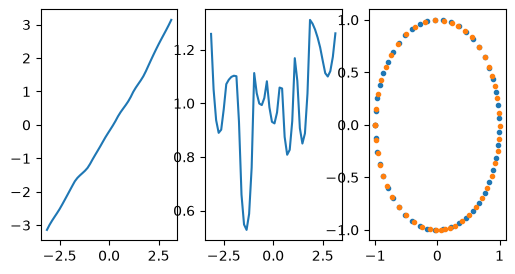

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(6, 3))
theta = jnp.linspace(-jnp.pi + 1e-3, jnp.pi - 1e-3, 50)
spl_circ = model_trained.bijection.transforms[-1].make_spline()
theta_out = eqx.filter_vmap(spl_circ)(theta)
axes[0].plot(theta, theta_out)
axes[1].plot(theta, eqx.filter_vmap(eqx.filter_grad(spl_circ))(theta))
axes[2].plot(jnp.cos(theta), jnp.sin(theta), ".")
axes[2].plot(jnp.cos(theta_out), jnp.sin(theta_out), ".")

In [ ]:
model_trained.bijection.transforms[4].center

AttributeError: 'InvertibleLinear' object has no attribute 'center'

In [49]:
u_train_ae = eqx.filter_vmap(
    lambda x: model_trained.bijection.inverse(model_trained.bijection(x))
)(u_train[:, 0])
jnp.max(jnp.abs(u_train[:, 0] - u_train_ae))

Array(6.03073147e-13, dtype=float64)

In [83]:
xy_grid = jnp.stack(
    jnp.meshgrid(jnp.linspace(-3, 3, 50), jnp.linspace(-3, 3, 50)), axis=-1
)
xy_grid.shape

(50, 50, 2)

In [39]:
from einops import rearrange


def bijection_err(bijection, x):
    x_ = bijection.inverse(bijection(x))
    return jnp.linalg.norm(x - x_)


biject_err = eqx.filter_vmap(bijection_err, in_axes=(None, 0))(
    model_trained.bijection, rearrange(xy_grid, "X Y C-> (X Y) C")
)

In [40]:
biject_err.shape

(2500,)

In [41]:
jnp.max(biject_err)

Array(2.27547975e-13, dtype=float64)

In [42]:
biject_err = rearrange(biject_err, "(X Y) -> X Y", X=xy_grid.shape[0])

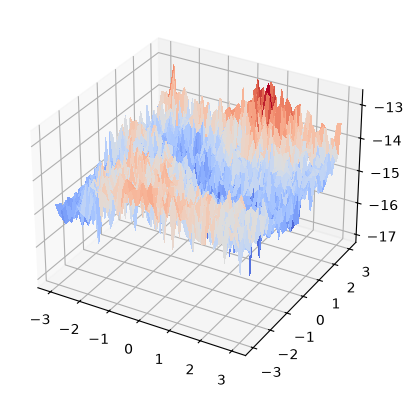

In [43]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
# Plot the surface.
surf = ax.plot_surface(
    xy_grid[..., 0],
    xy_grid[..., 1],
    jnp.log10(biject_err),
    cmap="coolwarm",
    linewidth=0,
    antialiased=False,
)